# Phân tích và trực quan hóa kết quả dự án Sentiment

Notebook tổng hợp kết quả tiền xử lý dữ liệu, phân tích cảm xúc khách hàng và đánh giá hệ thống gợi ý sản phẩm.

Mục tiêu:
- Khám phá dữ liệu đầu vào và đầu ra.
- Trực quan hóa phân phối cảm xúc.
- So sánh mô hình ALS cơ bản và mô hình tích hợp cảm xúc.
- Đưa ra nhận xét dựa trên các chỉ số đánh giá thực nghiệm.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14

print("Các thư viện đã sẵn sàng.")

Các thư viện đã sẵn sàng.


In [4]:
metrics = pd.DataFrame({
    "Mô hình": [
        "ALS cơ bản",
        "ALS tích hợp cảm xúc"
    ],
    "RMSE": [1.5543, 1.5451],
    "Precision@10": [0.092, 0.092],
    "NDCG@10": [0.920, 0.920]
})

display(metrics)

,Mô hình,RMSE,Precision@10,NDCG@10
0,ALS cơ bản,1.5543,0.092,0.92
1,ALS tích hợp cảm xúc,1.5451,0.092,0.92


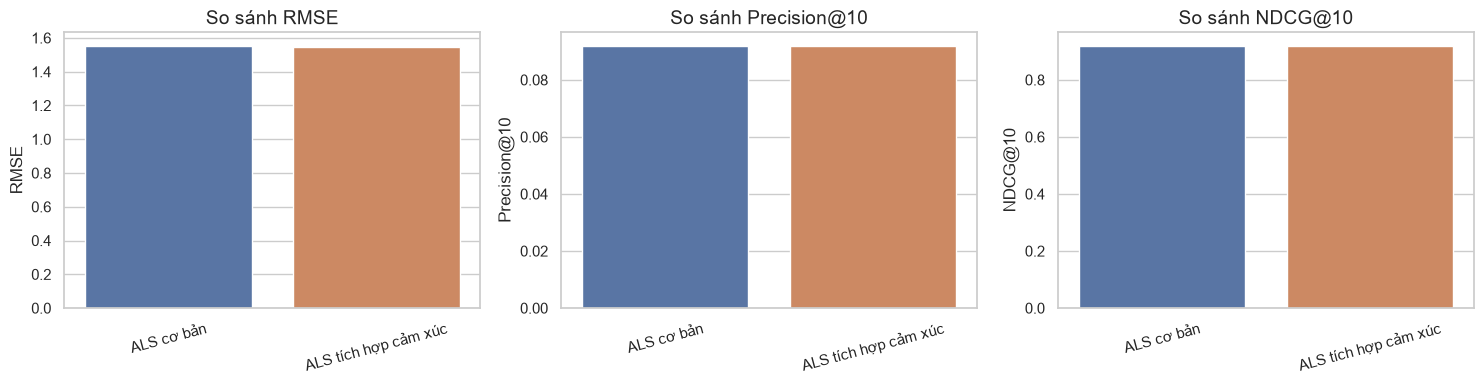

In [5]:
metric_columns = ["RMSE", "Precision@10", "NDCG@10"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, metric_columns):
    sns.barplot(
        data=metrics,
        x="Mô hình",
        y=metric,
        hue="Mô hình",
        legend=False,
        ax=ax
    )
    ax.set_title(f"So sánh {metric}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Tổng kết

RMSE giảm khoảng 0,59% — mức cải thiện khá nhỏ.

Precision@10 không đổi: trung bình tỷ lệ sản phẩm liên quan trong top 10 không tăng.

NDCG@10 không đổi: chất lượng thứ tự xếp hạng theo cách đánh giá hiện tại chưa thể hiện sự cải thiện.

Mục tiêu gốc “cá nhân hoá cải thiện nhờ sentiment” không khả thi.

# Nguyên nhân

Olist vốn không hợp cho collaborative filtering cá nhân hoá — do cấu trúc dữ liệu Olist (khách hàng không mua lặp lại), không phải lỗi thuật toán.

# Hướng khắc phục

Đổi dataset có khách hàng mua lặp lại (Amazon Reviews, Yelp) nếu muốn giữ mục tiêu cá nhân hoá.

Tích hợp lại thuật toán hybrid cũ để so sánh trực tiếp.